## Установка и импорт нужных библиотек

In [ ]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# !pip install -U langchain
# !pip install langchain-text-splitters
# !pip install -U sentence-transformers
# !pip install -U langchain-community
# !pip install -U langchain-huggingface

## Датасет

In [ ]:
df = pd.read_csv("websites_updated.csv", encoding="utf-8")
df.head(3)

,web_id,url,kind,title,text
0,1,https://alfabank.ru/,html,"Альфа-Банк - кредитные и дебетовые карты, кред...",Рассчитайте выгоду\nРасчёт калькулятора предва...
1,2,https://alfabank.ru/a-club/,html,А-Клуб. Деньги имеют значение,Брокерские услуги\nОткрытие брокерского счёта ...
2,3,https://alfabank.ru/a-club/ultimate/,html,А-Клуб. Деньги имеют значение,Хотите получить больше информации?\nПозвоните ...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   web_id  1938 non-null   int64 
 1   url     1938 non-null   object
 2   kind    1937 non-null   object
 3   title   1937 non-null   object
 4   text    1937 non-null   object
dtypes: int64(1), object(4)
memory usage: 75.8+ KB


In [ ]:
df.isna().sum() # пропусков мало

web_id    0
url       0
kind      1
title     1
text      1
dtype: int64

In [ ]:
df.nunique()

web_id    1938
url       1921
kind         2
title     1588
text      1921
dtype: int64

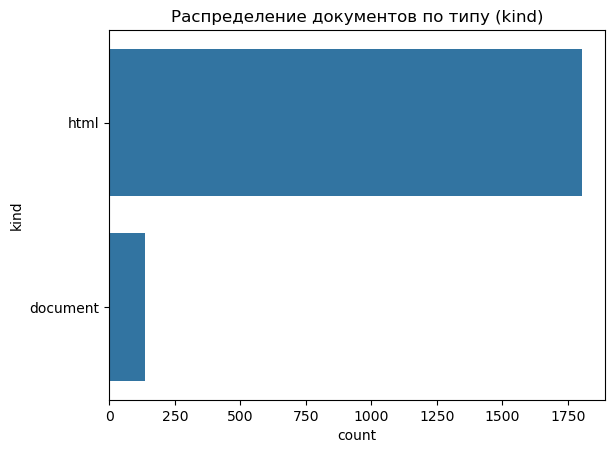

In [ ]:
sns.countplot(y="kind", data=df, order=df["kind"].value_counts().index)
plt.title("Распределение документов по типу (kind)")
plt.show()

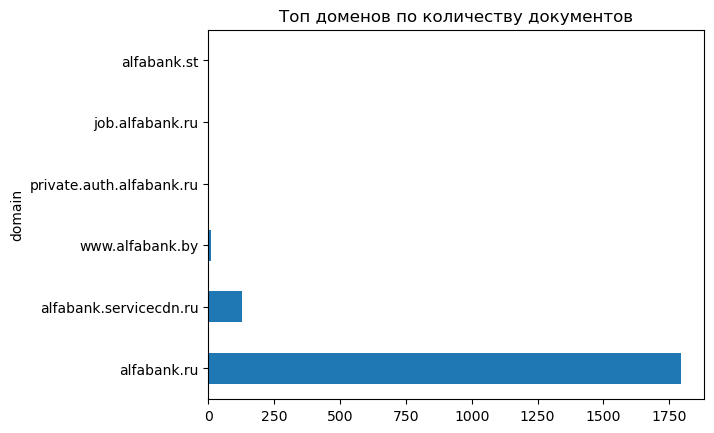

In [ ]:
df["domain"] = df["url"].str.extract(r"https?://([^/]+)/")
df["domain"].value_counts().plot(kind="barh")
plt.title("Топ доменов по количеству документов")
plt.show()

In [ ]:
# Частотность повторяющихся заголовков (кандидаты на дубликаты)
dup_titles = df["title"].value_counts()
pd.DataFrame(dup_titles[dup_titles > 1])

,count
title,
О внесении изменений в Договор о комплексном банковском обслуживании,126
О внесении изменений в Договор о комплексном банковском обслуживании,67
Об изменениях в Тарифы по Договору о комплексном банковском обслуживании физических лиц,32
Без названия,14
Об изменениях в Тарифы по Договору о комплексном банковском обслуживании физических лиц,13
...,...
Новая скорость бизнеса,2
Альфа-Банк: страница не найдена,2
Не могу забрать карту в назначенное время или назначенном месте. Что делать?,2


In [ ]:
# Частота стоп-слов или HTML-тегов
df["text"].str.contains(r"<[^>]+>").mean()

# Очистка не нужна

np.float64(0.002581311306143521)

In [ ]:
df["text_len_words"] = df["text"].astype(str).str.split().str.len() # кол-во слов в каждой строке

print("Средняя длина текста (в словах):", df["text_len_words"].mean())
print("Максимальная длина:", df["text_len_words"].max())
print("Минимальная длина:", df["text_len_words"].min())

Средняя длина текста (в словах): 863.8457172342621
Максимальная длина: 174641
Минимальная длина: 0


In [ ]:
# Одна строка с пропусками (удаляем)
missing_rows = df[df.isna().any(axis=1)]
print("Количество строк с пропусками:", len(missing_rows))
missing_rows.head()

Количество строк с пропусками: 1


,web_id,url,kind,title,text,domain,text_len_words
1937,1938,https://job.alfabank.ru/vacancies/moskva,NaN,NaN,NaN,job.alfabank.ru,1


In [ ]:
# Две строки с путым тексом
df[df["text"].str.strip() == ""]

,web_id,url,kind,title,text,domain,text_len_words
1706,1707,https://alfabank.servicecdn.ru/site-upload/c7/...,document,Private_s_1082025.pdf,,alfabank.servicecdn.ru,0
1877,1878,https://www.alfabank.by/upload/docs/bank/liche...,document,lichenzia.pdf,,www.alfabank.by,0


In [ ]:
# удаляю строки, где нет текста или он пустой
df = df[df["text"].notna() & (df["text"].str.strip() != "")]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1935 entries, 0 to 1936
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   web_id          1935 non-null   int64 
 1   url             1935 non-null   object
 2   kind            1935 non-null   object
 3   title           1935 non-null   object
 4   text            1935 non-null   object
 5   domain          1935 non-null   object
 6   text_len_words  1935 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 120.9+ KB


In [ ]:
print("Общая статистика по длине (в словах):")
df["text_len_words"].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99])

Общая статистика по длине (в словах):


count      1935.000000
mean        865.184496
std        5739.141822
min           1.000000
10%          33.000000
25%          77.500000
50%         300.000000
75%         999.500000
90%        1409.200000
95%        1831.300000
99%        6225.400000
max      174641.000000
Name: text_len_words, dtype: float64

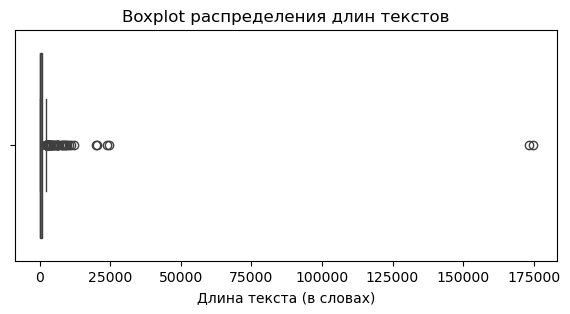

In [ ]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df["text_len_words"])
plt.xlabel("Длина текста (в словах)")
plt.title("Boxplot распределения длин текстов")
plt.show()

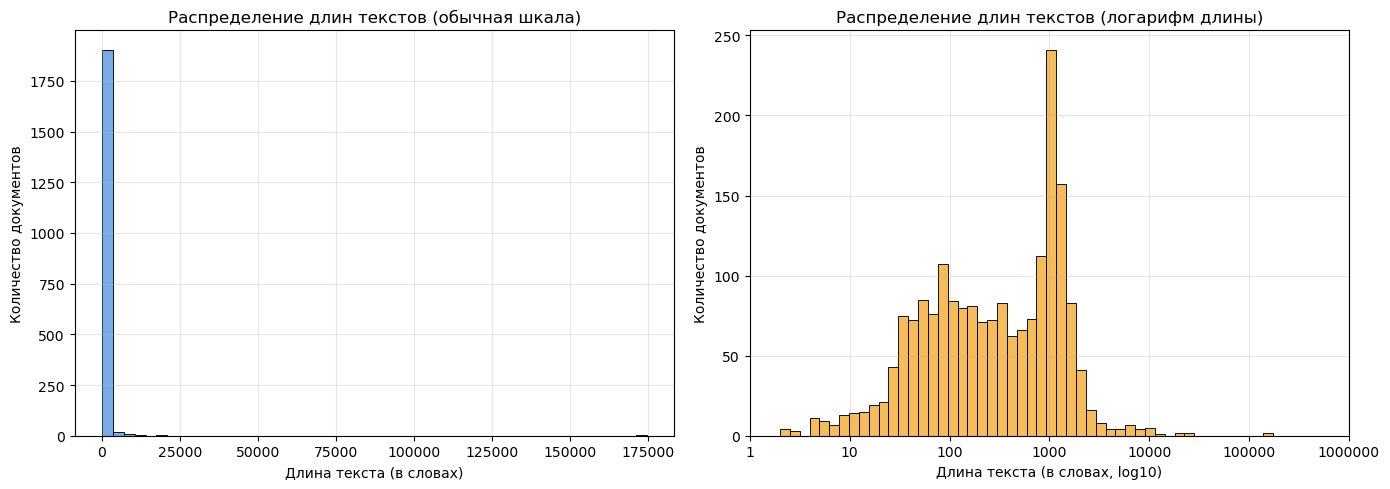

In [ ]:
df["log_len_words"] = np.log10(df["text_len_words"] + 1)

plt.figure(figsize=(14, 5))

# показывает реальное распределение, но длинные тексты почти не видны (то есть большинство страниц короткие)
plt.subplot(1, 2, 1)
sns.histplot(df["text_len_words"], bins=50, color="#4a90e2")
plt.xlabel("Длина текста (в словах)")
plt.ylabel("Количество документов")
plt.title("Распределение длин текстов (обычная шкала)")
plt.grid(alpha=0.3)

# логарифмированное распределение сжимает хвосты, теперь ты видно и короткие, и длинные тексты на одном графике
plt.subplot(1, 2, 2)
sns.histplot(df["log_len_words"], bins=50, color="#f5a623")

max_log = np.ceil(df["log_len_words"].max())
plt.xticks(
    ticks=np.arange(0, max_log + 1),
    labels=[f"{int(10**i)}" for i in range(int(max_log) + 1)]
)
plt.xlabel("Длина текста (в словах, log10)")
plt.ylabel("Количество документов")
plt.title("Распределение длин текстов (логарифм длины)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**ВЫВОД**
1. Корпус из 1935 текстов имеет высокую вариативность длин
2. Медианная длина составляет ~300 слов, при этом 95 % текстов короче 2000 слов.
3. Около 1 % документов превышают 10 000 слов — они искажают распределение.
4. Имеются дубликаты текстов.
5. Для большинства текстов оптимальный размер чанка — 1000 символов (≈200 слов) с перекрытием 100 символов.(совет гпт)
6. Мне кажется, можно оставить изначальный датасет

**ВОПРОСЫ:**
1. Аномально длинные документы (которых очень мало) оставляем? - наверное надо оставить, все равно будем делить на чанки.
2. Что делаем с пропусками и путыми значениями - при удалении лишаемся всего 3ех строк (с 1938 до 1935). Думаю, надо удалять. (в одной строке NaN, в двух - пустой текст "").
3. Дубликаты текста есть, но одни тексты относятся к разным url. Если оставить то retriever будет переоценивать такие документы (несколько идентичных чанков усилят их веса в векторном пространстве). Можно не трогать, удалить все дубликаты текста (df.drop_duplicates(subset=["text"]))- останется 1919 , оставить один экземпляр каждого URL (df.drop_duplicates(subset=["url"])) - останется 1918.

In [ ]:
df.nunique()

q_id        6977
web_list    6855
dtype: int64

In [ ]:
df = df.drop_duplicates(subset=["text"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1919 entries, 0 to 1936
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   web_id          1919 non-null   int64  
 1   url             1919 non-null   object 
 2   kind            1919 non-null   object 
 3   title           1919 non-null   object 
 4   text            1919 non-null   object 
 5   domain          1919 non-null   object 
 6   text_len_words  1919 non-null   int64  
 7   log_len_words   1919 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 134.9+ KB


In [ ]:
#df.to_csv("Websites_clean.csv", index=False, encoding="utf-8") # сохранение очищенного файла

## Разбиение документа на чанки

In [ ]:
# Прежде преобразую LangChain Document
from langchain_core.documents import Document

RAW_KNOWLEDGE_BASE = [
    Document(
        page_content=row["text"],
        metadata={
            "url": row["url"],
            "title": row["title"],
            "kind": row["kind"],
            "web_id": row["web_id"]
        }
    )
    for _, row in df.iterrows()
]

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# Мы используем иерархический список разделителей, специально предназначенных для разделения документов Markdown
# Этот список взят из класса MarkdownTextSplitter в LangChain

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # Максимальное количество символов в чанке
    chunk_overlap=100,  # Количество символов, которые будут перекрываться между чанками
    add_start_index=True,  # Если "True", то включает начальный индекс чанка в метаданные
    strip_whitespace=True,  # Если значение "True", то пробелы удаляются из начала и конца каждого документа
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])

Максимальная длина последовательности: 512


  0%|          | 0/16955 [00:00<?, ?it/s]

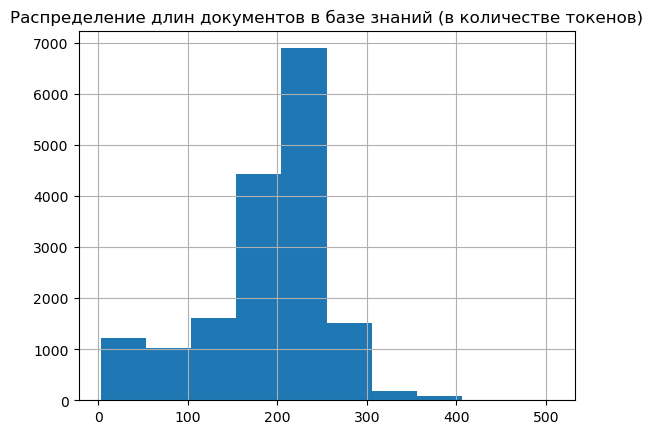

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("intfloat/multilingual-e5-large")
print("Максимальная длина последовательности:", model.max_seq_length)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-large")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

# Построим график распределения длин документов, подсчитываемых как количество токенов
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

Token indices sequence length is longer than the specified maximum sequence length for this model (647 > 512). Running this sequence through the model will result in indexing errors


  0%|          | 0/7435 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (514 > 512). Running this sequence through the model will result in indexing errors


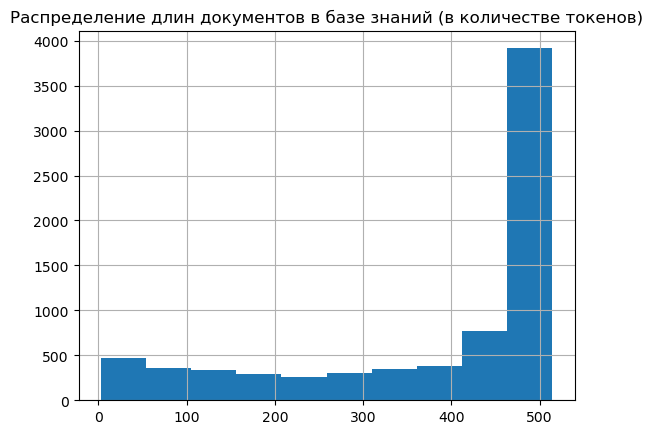

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-large"


def split_documents(
    chunk_size: int,
    knowledge_base: List[Document],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[Document]:
    """
    Разобъём документы на блоки максимального размера `chunk_size` и вернём список документов.
    """
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    # Удалим дубли
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    512,  # Выбираем размер чанка, соответствующий модели
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

# Представим размеры блоков, которые возможно получить в токенах из общей модели
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Распределение длин документов в базе знаний (в количестве токенов)")
plt.show()

## Процесс извлечения информации

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_community.embeddings import HuggingFaceEmbeddings

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    multi_process=True,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # `True` для косинусного сходства
)

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed, embedding_model, distance_strategy=DistanceStrategy.COSINE
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

NameError: name 'vectorstore' is not defined

In [ ]:
KNOWLEDGE_VECTOR_DATABASE.save_local("faiss_index")

In [ ]:
# можно проврерить визуализацией PCA

In [ ]:
# from langchain_community.vectorstores import FAISS
# db = FAISS.load_local("faiss_index", embedding_model, allow_dangerous_deserialization=True)

In [ ]:
from langchain_community.vectorstores import FAISS
retriever = FAISS.load_local(
    "faiss_index", embedding_model, allow_dangerous_deserialization=True
).as_retriever(search_kwargs={"k": 5})

In [ ]:
# проверка
query = "Здравствуйте . Могу ли я оформить кредит, чтоб деньги сразу поступили на карту в кабинет?"

In [ ]:
results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(query, k=5)

for (doc, score) in docs_scores:
    print(round(float(score), 4), d.metadata.get("title"))
    print(f"URL: {doc.metadata.get('url', '—')}")
    print(f"Фрагмент: {doc.page_content[:250]}...")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

0.2049 Как купить коммерческую недвижимость в ипотеку — Блог 🅰️ Альфа‑Банка
URL: https://alfabank.ru/get-money/mortgage/articles/kak-vzyat-ipoteku/
Фрагмент: пенсионное удостоверение.
Уточнить перечень документов можно в описании выбранного ипотечного кредита, в разделе «Полезно знать», вкладка «Необходимые документы».
Подать предварительную заявку на оформление ипотеки можно на сайте Альфа‑Банка. Для это...
0.2289 Как купить коммерческую недвижимость в ипотеку — Блог 🅰️ Альфа‑Банка
URL: https://alfabank.ru/get-money/mortgage/articles/kak-vzyat-ipoteku/
Фрагмент: Альфа‑Банк
Полезное о продуктах
Подайте заявку в банке. Альфа‑Банк предоставляет возможность подать заявление онлайн.
Получите предварительное одобрение. Обычно это занимает не более 2 или 5 минут.
Прикрепите скан-копии документов в личном кабинете.
...
0.2411 Как купить коммерческую недвижимость в ипотеку — Блог 🅰️ Альфа‑Банка
URL: https://alfabank.ru/get-money/mortgage/articles/kak-vzyat-ipoteku-na-vtorichnoe-zhile/
Фрагмент

## Сохранение ответа

In [ ]:
pd.read_csv("questions_clean.csv")

,q_id,query
0,1,Номер счета
1,2,Где узнать бик и счёт
2,3,Мне не приходят коды для подтверждения данной ...
3,4,"Оформила рассрочку ,но уведомлений никаких не ..."
4,5,"Здравствуйте, когда смогу пользоваться кредитн..."
...,...,...
6972,6973,"Здравствуйте, оплатил вчера ЖКХ а кэшбек не на..."
6973,6974,"Здравствуйте, можно ли заказать реквизиты бан..."
6974,6975,"Здравствуйте, подскажите пожалуйста где я могу..."
6975,6976,Реквизиты для оплаты номера карты


In [ ]:
#  Функция поиска top-k
def retrieve_topk(query, k=5):
    q = f"query: {query}"
    results = KNOWLEDGE_VECTOR_DATABASE.similarity_search_with_score(q, k=k)
    ids = [int(d.metadata.get("web_id")) for d, _ in results if d.metadata.get("web_id") is not None]
    return ids[:k]

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


questions = pd.read_csv("questions_clean.csv")

rows = []
for r in tqdm(questions.itertuples(), total=len(questions), desc="Retrieving"):
    top5_ids = retrieve_topk(r.query, k=5)
    rows.append({"q_id": int(r.q_id), "web_list": str(top5_ids)})

# сохраняем в CSV
df = pd.DataFrame(rows, columns=["q_id", "web_list"])
df.to_csv("retrieval_results.csv", index=False, encoding="utf-8")

print("Файл сохранён: retrieval_results.csv")

Retrieving:   0%|          | 0/6977 [00:00<?, ?it/s]

Файл сохранён: retrieval_results.csv


In [ ]:
df = pd.read_csv("retrieval_results.csv")
df

,q_id,web_list
0,1,"[1157, 1795, 372, 403, 372]"
1,2,"[372, 442, 363, 819, 1157]"
2,3,"[442, 116, 1730, 426, 88]"
3,4,"[251, 18, 426, 807, 442]"
4,5,"[1193, 43, 1039, 1038, 921]"
...,...,...
6972,6973,"[1902, 1040, 420, 1197, 60]"
6973,6974,"[1158, 398, 1157, 88, 368]"
6974,6975,"[442, 1544, 1666, 18, 1574]"
6975,6976,"[1567, 1072, 1896, 1757, 54]"
